<a href="https://colab.research.google.com/github/jennyt14/math-228-phys-insprd-machine-learning/blob/main/math_228_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving Black-Scholes Equation using Physics-Informed Neural Networks (PINNs)

By: Jenny Tran

In this project, we will use PINNs to solve the Black-Scholes PDE. The Black-Scholes equation is used to mathematically model for pricing options and other financial derivatives. The main idea is suppose you hold a stock option. The value of the stock option depends on the current stock price, how volatile the stock is, how much time is left until expiration, and the risk free interest rate. Black-Scholes tells use that given these inputs, there is one fair price for the option.

The Black-Scholes PDE for an option price $V(S,t)$ is:

$$\frac{\partial V}{\partial t} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 V}{ \partial S^2} + rS \frac{\partial V}{\partial S} - rV = 0$$


where
*   $S$ is the underlying asset price,
*   $t$ is time.
* $\sigma$ is the volatility.
* $r$ is the risk free interest rate.

We will use the following boundary/terminal conditions: for strike price $K$,


*   $V(S,T) = \max(S-K, 0)$
*   $V(0,t) = 0$
*   $V(S \to \infty, t) \approx S$



The closed-form solution is:
$$V(S,t) = S \cdot N(d_1) - Ke^{-r(T-t)} \cdot N(d_2)$$
where $$d_1 = \frac{\ln(S/K) + (r+ \frac{\sigma^2}{2})(T-t)}{\sigma \sqrt{T - t}}, \quad d_2 = d_1 - \sigma \sqrt{T-t},$$ and $N(\cdot)$ is the cumulative standard normal distribution.

In [ ]:
#import libraries
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
from scipy.stats import norm

np.random.seed(0)
torch.manual_seed(0)

## Black-Scholes Solution (Ground Truth)

In [ ]:
def bs_call(S, t, K, r, sigma, T):
  tau = T - t + 1e-6
  d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * tau) / (sigma * np.sqrt(tau))
  d2 = d1 - sigma * np.sqrt(tau)
  return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

print("Black-Scholes solution defined.")

Black-Scholes solution defined.


## Neural Network Architecture

In this project, we will use 6 hidden layers and 64 nodes in each layer. We use the $\tanh$ activiation function for the hidden layers.

In [ ]:
class PINN(nn.Module):
    def __init__(self, hidden_layers=6, hidden_size=64):
        super().__init__()
        layers = [nn.Linear(2, hidden_size), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 1))
        self.net = nn.Sequential(*layers)

        # Xavier initialization — important for smooth PDE landscapes
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, S, t):
        x = torch.cat([S, t], dim=1)   # shape: (N, 2)
        return self.net(x)             # shape: (N, 1)

## Physics Loss Function

Calculate the residual of the Black-Scholes PDE.

In [ ]:
def pde_residual(model, S, t, r, sigma):
  S = S.requires_grad_(True)
  t = t.requires_grad_(True)

  V = model(S,t)

  grads = torch.autograd.grad(
        V, [S, t],
        grad_outputs=torch.ones_like(V),
        create_graph=True
  )
  dV_dS, dV_dt = grads

  # Second-order derivative w.r.t. S
  d2V_dS2 = torch.autograd.grad(
      dV_dS, S,
      grad_outputs=torch.ones_like(dV_dS),
      create_graph=True
  )[0]

  # Black-Scholes residual
  residual = (dV_dt
              + 0.5 * sigma**2 * S**2 * d2V_dS2
              + r * S * dV_dS
              - r * V)
  return residual

## Sample Collocation Points
Generate training data to select collocation points in $(S,t)$. It generates various types of data points (interior points, terminal points, and boundary condition points) needed to train the PINN.

In [ ]:
def sample_points(n_pde, n_ic, n_bc, S_max, T):
    # Interior: random (S, t) pairs
    S_pde = torch.FloatTensor(n_pde, 1).uniform_(0.01, S_max)
    t_pde = torch.FloatTensor(n_pde, 1).uniform_(0.0, T)

    # Terminal condition (t = T)
    S_ic = torch.FloatTensor(n_ic, 1).uniform_(0.01, S_max)
    t_ic = torch.full((n_ic, 1), T)

    # Boundary S = 0
    S_bc0 = torch.zeros(n_bc, 1)
    t_bc0 = torch.FloatTensor(n_bc, 1).uniform_(0.0, T)

    # Boundary S = S_max
    S_bcM = torch.full((n_bc, 1), S_max)
    t_bcM = torch.FloatTensor(n_bc, 1).uniform_(0.0, T)

    return (S_pde, t_pde, S_ic, t_ic, S_bc0, t_bc0, S_bcM, t_bcM)

## Loss Function

Computes $$\text{Total Loss} = w_{\text{pde}}L_{\text{pde}} + w_{\text{ic}}L_{\text{ic}} + w_{\text{bc}}L_{\text{bc}}$$ where $w_{\text{pde}} = 1$, $w_{\text{ic}} = 10$, and $w_{\text{bc}} = 5$.

In [ ]:
def compute_loss(model, points, K, r, sigma, T,
                 w_pde=1.0, w_ic=10.0, w_bc=5.0):
    S_pde, t_pde, S_ic, t_ic, S_bc0, t_bc0, S_bcM, t_bcM = points

    # PDE residual loss
    res = pde_residual(model, S_pde, t_pde, r, sigma)
    loss_pde = torch.mean(res**2)

    # Terminal condition: V(S, T) = max(S - K, 0)
    V_ic = model(S_ic, t_ic)
    payoff = torch.clamp(S_ic - K, min=0.0)
    loss_ic = torch.mean((V_ic - payoff)**2)

    # Boundary S = 0: V = 0
    V_bc0 = model(S_bc0, t_bc0)
    loss_bc0 = torch.mean(V_bc0**2)

    # Boundary S = S_max: V ≈ S_max - K*exp(-r*(T-t))
    tau_bcM = T - t_bcM
    V_bcM_exact = S_bcM - K * torch.exp(-r * tau_bcM)
    V_bcM_pred  = model(S_bcM, t_bcM)
    loss_bcM = torch.mean((V_bcM_pred - V_bcM_exact)**2)

    loss_bc = loss_bc0 + loss_bcM

    total = w_pde * loss_pde + w_ic * loss_ic + w_bc * loss_bc
    return total, loss_pde.item(), loss_ic.item(), loss_bc.item()

## Train Neural Network

In [ ]:
def train(model, K, r, sigma, T, S_max,
          n_epochs=5000, lr=1e-3,
          n_pde=2000, n_ic=500, n_bc=500):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # LR scheduler: halve LR every 2000 steps
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

    history = {"total": [], "pde": [], "ic": [], "bc": []}

    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()

        # Resample every epoch for better generalization
        points = sample_points(n_pde, n_ic, n_bc, S_max, T)

        loss, l_pde, l_ic, l_bc = compute_loss(
            model, points, K, r, sigma, T
        )
        loss.backward()
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        history["total"].append(loss.item())
        history["pde"].append(l_pde)
        history["ic"].append(l_ic)
        history["bc"].append(l_bc)

        if epoch % 500 == 0 or epoch == 1:
            print(f"Epoch {epoch:5d} | Total: {loss.item():.2e} | "
                  f"PDE: {l_pde:.2e} | IC: {l_ic:.2e} | BC: {l_bc:.2e} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e}")

    return history

## Evaluation

In [ ]:
def evaluate_and_plot(model, K, r, sigma, T, S_max):
    model.eval()

    # Grid for S values
    S_vals = np.linspace(0.01, S_max, 200)
    t_val = T / 3

    fig, ax = plt.subplots(figsize=(9, 6)) # Single plot, adjust size
    fig.suptitle(f"Black-Scholes PINN vs Analytical Solution at t={t_val:.2f}", fontsize=14)

    # Prepare S and t tensors for the model
    S_t = torch.FloatTensor(S_vals).reshape(-1, 1)
    t_t = torch.full_like(S_t, t_val)

    with torch.no_grad():
        V_pred = model(S_t, t_t).cpu().numpy().flatten()

    V_exact = bs_call(S_vals, t_val, K, r, sigma, T)

    # Plot PINN and Exact solutions
    ax.plot(S_vals, V_pred,  color="#D81B60", lw=2, label=f"PINN t={t_val:.2f}")
    ax.plot(S_vals, V_exact, color="#1E88E5", lw=1.5, ls="--", label=f"Exact t={t_val:.2f}")

    ax.axvline(K, color="black", ls=":", lw=1, label=f"Strike K={K}")
    ax.set_xlabel("Stock Price S")
    ax.set_ylabel("Option Value V(S,t)")
    ax.set_title("Option Price Curve")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Print Error
    abs_error = np.abs(V_pred - V_exact)
    print(f"\nMax absolute error at t={t_val:.2f}: {abs_error.max():.4f}")
    print(f"Mean absolute error at t={t_val:.2f}: {abs_error.mean():.4f}")


def plot_loss(history):
    fig, ax = plt.subplots(figsize=(8, 4))
    for key, color in zip(["total", "pde", "ic", "bc"],
                          ["#5B7E3C", "#8A5F41", "#767F9E", "#FE81D4"]):
        ax.semilogy(history[key], label=key.upper(), color=color, lw=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (log scale)")
    ax.set_title("Training Loss History")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

## Main

Here, we will run the model and plot our results.

In [ ]:
# Black-Scholes Parameters
K = 100.0  # Strike Price
r = 0.05   # Risk-free rate
sigma = 0.2  # Volatility
T = 1.0    # Time to Expiration
S_max = 200.0 # Maximum stock price for boundary conditions

model = PINN(hidden_layers=6, hidden_size=64)

In [ ]:
# Train the model
history = train(model, K, r, sigma, T, S_max,
                n_epochs=5000, lr=1e-3,
                n_pde=2000, n_ic=500, n_bc=500)
print("\nModel training complete.")

Epoch     1 | Total: 6.92e+04 | PDE: 1.02e-03 | IC: 1.61e+03 | BC: 1.06e+04 | LR: 1.00e-03
Epoch   500 | Total: 3.28e+04 | PDE: 2.71e+01 | IC: 5.93e+02 | BC: 5.37e+03 | LR: 1.00e-03
Epoch  1000 | Total: 2.14e+04 | PDE: 1.01e+01 | IC: 3.61e+02 | BC: 3.56e+03 | LR: 1.00e-03
Epoch  1500 | Total: 1.31e+04 | PDE: 1.43e+01 | IC: 1.52e+02 | BC: 2.31e+03 | LR: 1.00e-03
Epoch  2000 | Total: 8.44e+03 | PDE: 1.97e+01 | IC: 1.02e+02 | BC: 1.48e+03 | LR: 5.00e-04
Epoch  2500 | Total: 5.19e+03 | PDE: 2.48e+01 | IC: 3.45e+01 | BC: 9.64e+02 | LR: 5.00e-04
Epoch  3000 | Total: 3.53e+03 | PDE: 3.61e+01 | IC: 2.28e+01 | BC: 6.53e+02 | LR: 5.00e-04
Epoch  3500 | Total: 2.36e+03 | PDE: 5.24e+01 | IC: 1.30e+01 | BC: 4.35e+02 | LR: 5.00e-04
Epoch  4000 | Total: 1.53e+03 | PDE: 5.34e+01 | IC: 6.22e+00 | BC: 2.82e+02 | LR: 2.50e-04
Epoch  4500 | Total: 1.10e+03 | PDE: 6.64e+01 | IC: 3.45e+00 | BC: 1.99e+02 | LR: 2.50e-04
Epoch  5000 | Total: 6.98e+02 | PDE: 9.31e+01 | IC: 3.69e+00 | BC: 1.14e+02 | LR: 2.50e-04

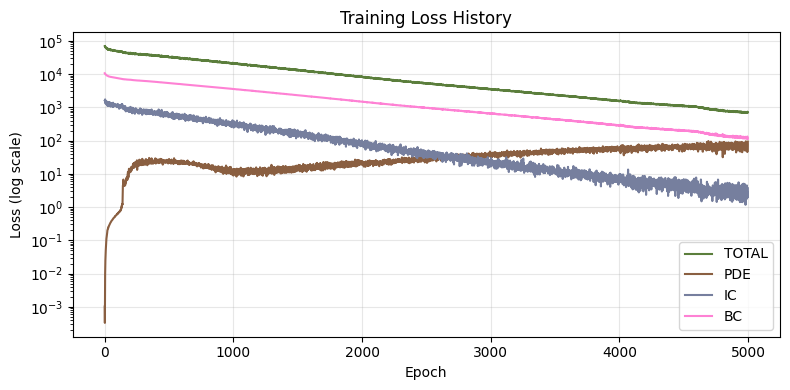

In [ ]:
# Plot the loss history
plot_loss(history)

We would want the four curves to converge to a very small value, but the losses are still very large and declining slowly.


Max absolute error at t=0.33: 11.4821
Mean absolute error at t=0.33: 1.6396


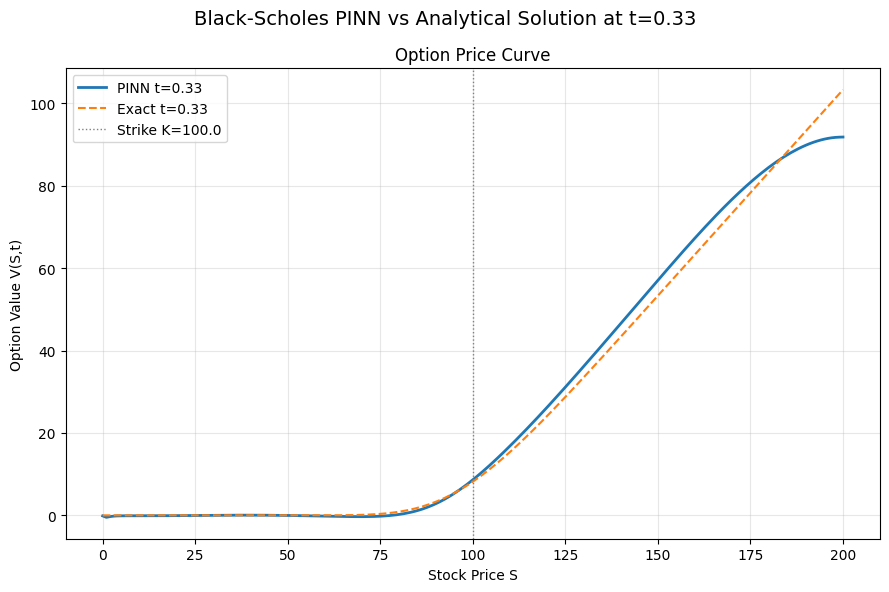

In [ ]:
# Evaluate and plot the PINN solution
evaluate_and_plot(model, K, r, sigma, T, S_max)

The result above show the option price $V(S,t)$ vs the stock price $S$ at a fixed time $t = 0.33$ (about $1/3$ of the way through the year).

On the left of the gray line where $S = 100$, the stock price is below the strike, so the option has little value.

On the right of the gray line, the option is increasingly valuable as $S$ grows. The PINN is not as accurate on the right as it is on the left of the strike price line.

## Future Areas to Explore

There are many parameters we can change in the code to improve the model. For example, we can change the weights in the total loss function, the learning rate, the number of epochs, etc.

Another variation of this problem that we can look at is the inverse PINN Black-Scholes problem where we are given our model and want to find the parameters.
